# Visium HD 3' (peak)

This notebook demonstrates essential steps for analyzing spatial transcriptome 3' end diversity (TREND) using **Visium HD 3' sequencing data** (peak-level). 

1. Load preprocessed peak-level quantification.
2. Run FFT-accelerated spatial variability tests with `SplisosmFFT`.
3. Compare SV test results across spatial resolutions.
4. Compare results across spatial resolutions and with `SplisosmNP`.

For differential usage testing with `SplisosmFFT`, see the [Visium HD FFPE (probe) Part II tutorial](./visiumhd_ffpe_du.ipynb).

Estimated runtime: ~20 min.

## Preliminary notes

3' end sequencing data captures variation near the 3' end of transcripts (alternative last exon, alternative polyadenylation etc.) as well as around intronic poly-A-rich regions. We jointly refer to these as transcriptome 3' end diversity (TREND) events. 

To run the analysis, we first call junction-aware peaks from the BAM file using [Sierra](https://github.com/VCCRI/Sierra), then quantify peak-level expression in each Visium HD bin using [UMI-tools](https://umi-tools.readthedocs.io/en/latest/index.html). An example workflow is provided in `scripts/visiumhd_3p_trend_quant.sh` under the [scripts directory](https://github.com/JiayuSuPKU/SPLISOSM/tree/main/scripts), which generates a peak-level `SpatialData` object stored as a `.zarr` file.

## Imports

In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import warnings

import annsel as an
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import spatialdata as sd
import spatialdata_plot
from spatialdata import rasterize_bins

from splisosm import SplisosmFFT, SplisosmNP
from splisosm.utils import counts_to_ratios

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (6, 4)

## Configure paths and core parameters

In [3]:
# Path to the preprocessed peak-level SpatialData zarr
sdata_zarr = Path("path/to/sdata_peak.filtered.zarr")

# Optional path to Sierra-called peaks in BED12 format (for visualization)
bed12_file = Path("path/to/peak.txt.bed12")
# Optional path to GTF annotation (for visualization)
gtf_file = Path("path/to/gencode.vM33.annotation.gtf.gz")

# Dataset and table identifiers (16um binning used throughout)
dataset_id = ""
test_table = "square_016um"
test_bins_element = f"{dataset_id}_square_016um"

# Peak annotation column names
group_iso_by = "gene_ids"
gene_name_col = "gene_ids"
candidate_gene_name_cols = ["gene_name", "gene_ids", "gene_symbol", "gene_names"]

# Peak QC filters
min_counts = 10
min_bin_pct = 0.01

In [4]:
# local path
sdata_zarr = Path("/Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_3p_mouse_cbs/sdata_peak.filtered.zarr")
bed12_file = Path("/Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_3p_mouse_cbs/sierra_peaks/peak.txt.bed12")
gtf_file = Path("/Users/jysumac/reference/mm39/gencode.vM33.annotation.gtf.gz")

## Load preprocessed peak-level `SpatialData`

In this example, we use a [Visium HD 3' mouse brain dataset (fresh frozen)](https://www.10xgenomics.com/datasets/visium-hd-three-prime-mouse-brain-fresh-frozen) provided by 10x Genomics. We load the preprocessed, peak-level `SpatialData` object generated by our custom quantification workflow (`scripts/visiumhd_3p_trend_quant.sh`). The resulting Sierra peak quantification matrix is located at `outs/binned_outputs/square_002um/raw_probe_bc_matrix.h5`.

In [5]:
%%time
if sdata_zarr.exists():
    print("Loading preprocessed SpatialData...")
    sdata = sd.read_zarr(sdata_zarr)
else:
    print("Building peak-level SpatialData from quantification outputs...")
    from splisosm.io import load_visiumhd_peak
    sdata = load_visiumhd_peak(
        path='path/to/outs',
        bin_sizes=bin_sizes,
        filtered_counts_file=True,
        load_all_images=False,
        var_names_make_unique=True,
        counts_layer_name="counts",
    )
    # Optional: cache for future runs
    # sdata.write(sdata_zarr)

sdata

Loading preprocessed SpatialData...


CPU times: user 6.99 s, sys: 1.67 s, total: 8.66 s
Wall time: 5.91 s


SpatialData object, with associated Zarr store: /Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_3p_mouse_cbs/sdata_peak.filtered.zarr
├── Images
│     ├── '_hires_image': DataArray[cyx] (3, 5492, 6000)
│     └── '_lowres_image': DataArray[cyx] (3, 549, 600)
├── Shapes
│     ├── '_cell_segmentations': GeoDataFrame shape: (84031, 2) (2D shapes)
│     ├── '_square_002um': GeoDataFrame shape: (5998466, 1) (2D shapes)
│     ├── '_square_008um': GeoDataFrame shape: (376419, 1) (2D shapes)
│     └── '_square_016um': GeoDataFrame shape: (94592, 1) (2D shapes)
└── Tables
      ├── 'cell_segmentations': AnnData (84031, 19575)
      ├── 'square_002um': AnnData (5998466, 19575)
      ├── 'square_008um': AnnData (376419, 19575)
      └── 'square_016um': AnnData (94592, 19575)
with coordinate systems:
    ▸ '', with elements:
        _hires_image (Images), _lowres_image (Images), _cell_segmentations (Shapes), _square_002um (Shapes), _square_008um (Shapes), _square_016um (Shapes)
    ▸ '_downsca

SPLISOSM can be run at any spatial resolution, but data become sparser at finer scales.

In [6]:
def summarize_table(adata):
    X = adata.layers["counts"] if "counts" in adata.layers else adata.X
    if hasattr(X, "nnz"):
        nnz = int(X.nnz)
        total = int(X.shape[0] * X.shape[1])
        density = nnz / total if total else np.nan
    else:
        arr = np.asarray(X)
        nnz = int(np.count_nonzero(arr))
        total = int(arr.size)
        density = nnz / total if total else np.nan
    return {
        "n_peaks": int(adata.n_vars),
        "n_bins": int(adata.n_obs),
        "count_mtx_density": density,
    }

rows = []
for key in sorted(sdata.tables.keys()):
    if key.startswith("square_"):
        rows.append({"table": key, **summarize_table(sdata.tables[key])})

table_summary = pd.DataFrame(rows).sort_values("table")
table_summary

,table,n_peaks,n_bins,count_mtx_density
0,square_002um,19575,5998466,0.000437
1,square_008um,19575,376419,0.006380
2,square_016um,19575,94592,0.022677


To balance sparsity and computation, we recommend `16µm` or `8µm` bins for initial analysis. Resolution comparison is shown at the end of this notebook.

In [7]:
# Optional: inspect available coordinate systems and image/shape keys
print("Tables:", sorted(sdata.tables.keys()))
print("Images:", sorted(getattr(sdata, "images", {}).keys()))
print("Shapes:", sorted(getattr(sdata, "shapes", {}).keys()))

# Quick guardrails before model setup
if test_table not in sdata.tables:
    raise ValueError(f"{test_table} is not available. Choose from: {sorted(sdata.tables.keys())}")

adata_test = sdata.tables[test_table]
if group_iso_by not in adata_test.var.columns:
    raise ValueError(f"{group_iso_by} not found in {test_table}.var columns")

if gene_name_col not in adata_test.var.columns:
    for col in candidate_gene_name_cols:
        if col in adata_test.var.columns:
            gene_name_col = col
            break

print(f"Using table={test_table}, bins={test_bins_element}")
print(f"Grouping column={group_iso_by}, display names={gene_name_col}")

Tables: ['cell_segmentations', 'square_002um', 'square_008um', 'square_016um']
Images: ['_hires_image', '_lowres_image']
Shapes: ['_cell_segmentations', '_square_002um', '_square_008um', '_square_016um']
Using table=square_016um, bins=_square_016um
Grouping column=gene_ids, display names=gene_ids


The features in this dataset represent peaks (spanning single exons or splice junctions) identified using `Sierra`'s `FindPeaks` function. These peaks were subsequently annotated based on their overlap with coding sequences (CDS), untranslated regions (UTR3 and UTR5), or intronic regions using `AnnotatePeaksFromGTF(annotation_correction=FALSE)`.

In [8]:
sdata.tables[test_table].var.head(5)

,gene_ids,probe_ids,feature_types,CDS,Junctions,UTR3,UTR5,end,exon,genome,intron,seqnames,start,strand,width
0610009B22Rik:chr11:51576213-51576468:-1,0610009B22Rik,0610009B22Rik:chr11:51576213-51576468:-1,Gene Expression,,no-junctions,YES,,51576468,YES,,,chr11,51576213,-,256
0610009L18Rik:chr11:120241627-120242029:1,0610009L18Rik,0610009L18Rik:chr11:120241627-120242029:1,Gene Expression,,no-junctions,,,120242029,YES,,,chr11,120241627,+,403
0610030E20Rik:chr6:72329741-72330131:1,0610030E20Rik,0610030E20Rik:chr6:72329741-72330131:1,Gene Expression,,no-junctions,YES,,72330131,YES,,,chr6,72329741,+,391
0610040B10Rik:chr5:143318096-143318420:1,0610040B10Rik,0610040B10Rik:chr5:143318096-143318420:1,Gene Expression,,no-junctions,,,143318420,YES,,,chr5,143318096,+,325
0610040J01Rik:chr5:64056587-64056953:1,0610040J01Rik,0610040J01Rik:chr5:64056587-64056953:1,Gene Expression,,no-junctions,YES,,64056953,YES,,,chr5,64056587,+,367


Use `spatialdata-plot` to visualize tissue morphology:

CPU times: user 3.2 s, sys: 200 ms, total: 3.4 s
Wall time: 3.53 s


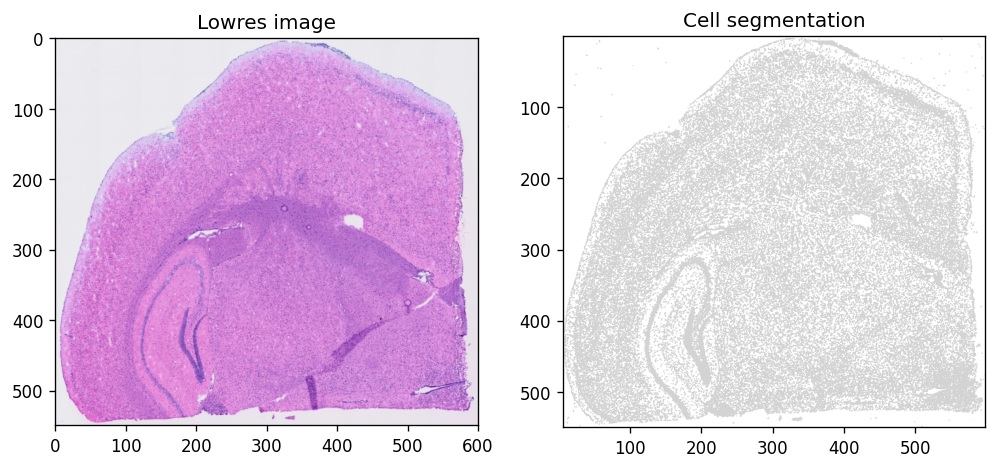

In [9]:
%%time
axes = plt.subplots(1, 2, figsize=(10, 5))[1].flatten()
sdata.pl.render_images(f"{dataset_id}_lowres_image").pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[0], title="Lowres image"
)
sdata.pl.render_shapes(f"{dataset_id}_cell_segmentations").pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[1], title="Cell segmentation"
)

To visualize peak expression as an image, rasterize the spatial bins first:

In [10]:
%%time
for bin_size in ["016", "008", "002"]:
    # rasterize_bins() requires a compressed sparse column (csc) matrix
    sdata.tables[f"square_{bin_size}um"].X = sdata.tables[f"square_{bin_size}um"].X.tocsc()
    rasterized = rasterize_bins(
        sdata,
        f"{dataset_id}_square_{bin_size}um",
        f"square_{bin_size}um",
        "array_col",
        "array_row",
    )
    sdata[f"rasterized_{bin_size}um"] = rasterized

CPU times: user 3.76 s, sys: 814 ms, total: 4.57 s
Wall time: 4.65 s


Then visualize a peak's global expression at 16µm resolution:

Using example feature: Map4:chr9:109912632-109913023:1


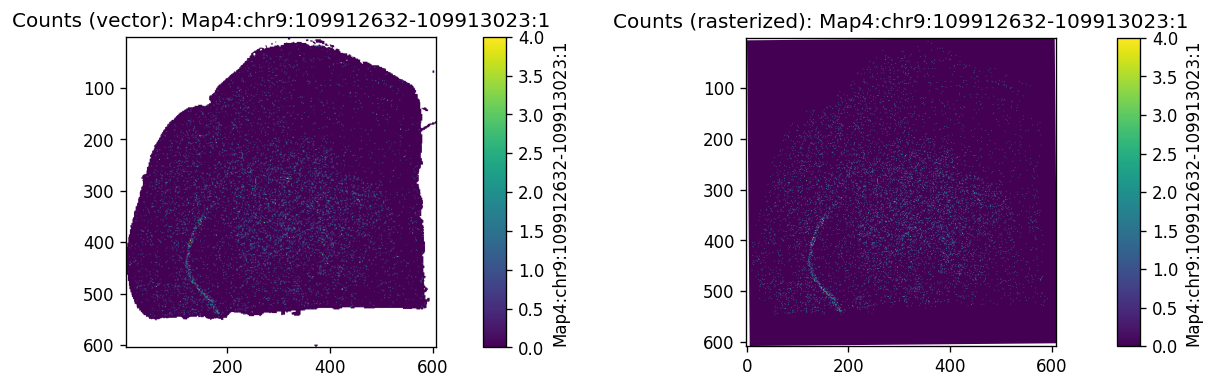

CPU times: user 5.8 s, sys: 1.61 s, total: 7.41 s
Wall time: 7.89 s


In [11]:
%%time
peak_name = 'Map4:chr9:109912632-109913023:1'
print(f"Using example feature: {peak_name}")

axes = plt.subplots(1, 2, figsize=(10, 5))[1].flatten()
sdata.pl.render_shapes(f"{dataset_id}_square_016um", color=peak_name).pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[0], title=f"Counts (vector): {peak_name}"
)
sdata.pl.render_images(f"rasterized_016um", channel=peak_name).pl.show(
    coordinate_systems=f"{dataset_id}_downscaled_lowres",
    ax=axes[1], title=f"Counts (rasterized): {peak_name}"
)
plt.subplots_adjust(wspace=1)
plt.show()

## Spatial variability testing with `SplisosmFFT`

To detect peak usage variation within a given gene, we run spatial variability test using `hsic-ir`.

### Filtering and model setup

Peak filtering criteria:
- `min_counts`: minimum total UMI count across all bins.
- `min_bin_pct`: minimum fraction of bins in which a peak must be detected.
- Genes with fewer than two passing peaks are automatically excluded.

In [12]:
model = SplisosmFFT(neighbor_degree=1, rho=0.99)
model.setup_data(
    sdata=sdata,
    bins=test_bins_element,
    table_name=test_table,
    col_key="array_col",
    row_key="array_row",
    layer="counts",
    group_iso_by=group_iso_by, # 'gene_ids'
    gene_names=gene_name_col, # 'gene_ids'
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    filter_single_iso_genes=True
)
model

=== SplisosmFFT
- Number of genes: 1061
- Number of spots: 94592
- Number of spots after rasterization: 134688
- Number of covariates: 0
- Average isoforms per gene: 2.2
=== Model configurations
- Neighborhood degree: 1
- Spatial autocorrelation rho: 0.99
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

Extract gene-level summary statistics:

In [13]:
%%time
gene_meta = model.extract_feature_summary(level='gene')
gene_meta.sort_values('perplexity', ascending=False).head(5)

Genes:   0%|          | 0/1061 [00:00<?, ?it/s]

Genes:  13%|█▎        | 135/1061 [00:00<00:00, 1337.53it/s]

Genes:  26%|██▋       | 280/1061 [00:00<00:00, 1401.60it/s]

Genes:  41%|████      | 430/1061 [00:00<00:00, 1441.32it/s]

Genes:  55%|█████▍    | 582/1061 [00:00<00:00, 1471.36it/s]

...

Genes:  83%|████████▎ | 877/1061 [00:00<00:00, 1468.44it/s]

Genes:  97%|█████████▋| 1031/1061 [00:00<00:00, 1491.34it/s]

Genes: 100%|██████████| 1061/1061 [00:00<00:00, 1456.07it/s]

CPU times: user 780 ms, sys: 129 ms, total: 909 ms
Wall time: 912 ms


,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
gene,,,,,,
Ppp3ca,6,4.951889,0.407138,0.869429,1.597794,0.307328
Celf4,5,3.819581,0.202174,0.250539,0.552908,0.477362
Homer1,4,3.788384,0.063769,0.070535,0.283515,0.364508
Pcmt1,4,3.785652,0.139145,0.161441,0.432617,0.378561
Rbbp6,4,3.780505,0.081297,0.087640,0.305624,0.332931


Peak-level summary is also available:

In [14]:
peak_meta = model.extract_feature_summary(level='isoform')
peak_meta.sort_values('gene_ids', ascending=False).head(5)

,gene_ids,probe_ids,feature_types,CDS,Junctions,UTR3,UTR5,end,exon,genome,...,start,strand,width,pct_bin_on,count_total,count_avg,count_std,ratio_total,ratio_avg,ratio_std
mt-Nd5:chrM:12597-13503:1,mt-Nd5,mt-Nd5:chrM:12597-13503:1,Gene Expression,YES,no-junctions,,,13503,YES,,...,12597,+,907,0.295427,35035.0,0.370380,0.642801,0.672909,0.670371,0.432255
mt-Nd5:chrM:11870-13196:1,mt-Nd5,mt-Nd5:chrM:11870-13196:1,Gene Expression,YES,no-junctions,,,13196,YES,,...,11870,+,1327,0.135720,14026.0,0.148279,0.391148,0.269394,0.271458,0.408964
mt-Nd5:chrM:11742-12338:1,mt-Nd5,mt-Nd5:chrM:11742-12338:1,Gene Expression,YES,no-junctions,,,12338,YES,,...,11742,+,597,0.031123,3004.0,0.031757,0.178934,0.057697,0.058170,0.215502
mt-Nd4:chrM:11161-11413:1,mt-Nd4,mt-Nd4:chrM:11161-11413:1,Gene Expression,YES,no-junctions,,,11413,YES,,...,11161,+,253,0.906726,332118.0,3.511058,2.643438,0.937358,0.936997,0.150768
mt-Nd4:chrM:11100-11519:1,mt-Nd4,mt-Nd4:chrM:11100-11519:1,Gene Expression,YES,across-junctions,,,11519,YES,,...,11100,+,420,0.168820,17843.0,0.188631,0.443044,0.050359,0.050763,0.136139


### Running HSIC-IR test

In [15]:
%%time
model.test_spatial_variability(
    method="hsic-ir",
    ratio_transformation="none",
    n_jobs=-1,
    print_progress=True,
)
sv_res_16um = model.get_formatted_test_results(
    "sv", with_gene_summary=True
).sort_values("pvalue_adj")

SV [hsic-ir]:   0%|          | 0/1061 [00:00<?, ?it/s]

SV [hsic-ir]:   3%|▎         | 30/1061 [00:00<00:04, 226.02it/s]

SV [hsic-ir]:   5%|▍         | 53/1061 [00:00<00:05, 177.19it/s]

SV [hsic-ir]:   7%|▋         | 72/1061 [00:00<00:06, 160.62it/s]

SV [hsic-ir]:   8%|▊         | 90/1061 [00:00<00:06, 151.35it/s]

...

SV [hsic-ir]:  96%|█████████▌| 1020/1061 [00:08<00:00, 120.65it/s]

SV [hsic-ir]:  98%|█████████▊| 1040/1061 [00:08<00:00, 116.87it/s]

SV [hsic-ir]: 100%|█████████▉| 1060/1061 [00:08<00:00, 120.15it/s]

SV [hsic-ir]: 100%|██████████| 1061/1061 [00:08<00:00, 123.04it/s]

CPU times: user 16.1 s, sys: 3.56 s, total: 19.7 s
Wall time: 8.75 s


Top genes, sorted by adjusted p-value:

In [16]:
sig_001 = int((sv_res_16um["pvalue_adj"] < 0.01).sum())
print(
    "Spatially variably processed genes (FDR < 0.01, 16um): "
    f"{sig_001} out of {sv_res_16um.shape[0]} total genes"
)
sv_res_16um.head(5)

Spatially variably processed genes (FDR < 0.01, 16um): 506 out of 1061 total genes


,gene,statistic,pvalue,pvalue_adj,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
811,Septin8,1.398869e-06,0.0,0.0,3,2.184668,0.113213,0.125941,0.372038,0.707295
382,Gpm6b,1.697766e-06,0.0,0.0,2,1.544330,0.348698,0.466562,0.747658,0.843043
840,Slc8a1,6.530548e-07,0.0,0.0,3,2.737542,0.059466,0.065788,0.274655,0.541539
357,Gls,6.126092e-07,0.0,0.0,2,1.514386,0.124408,0.143976,0.411355,0.854395
138,Camk1d,7.656467e-07,0.0,0.0,2,1.905026,0.091213,0.101795,0.340931,0.654689


## Visualize significant events

The helper below renders per-peak **log1p counts** and **within-gene ratios** on the testing grid.

In [17]:
def ensure_rasterized(sdata, bin_table: str, bin_element: str, layer: str = "counts"):
    raster_key = f"rasterized_{bin_table}_{layer}"
    if raster_key in sdata.images:
        return raster_key

    adata = sdata.tables[bin_table]
    adata.X = adata.layers[layer]
    if hasattr(adata.X, "tocsc") and getattr(adata.X, "format", None) != "csc":
        adata.X = adata.X.tocsc()

    sdata[raster_key] = rasterize_bins(
        sdata,
        bins=bin_element,
        table_name=bin_table,
        col_key="array_col",
        row_key="array_row",
    )
    return raster_key

The plotting function checks peak availability, lazily rasterizes data on demand, computes log1p counts and within-gene ratios, and optionally masks zero values.

In [18]:
def plot_gene_peak_maps(
    sdata,
    bin_table: str,
    bin_element: str,
    gene_id: str,
    peak_meta: pd.DataFrame | None = None,
    group_col: str = "gene_ids",
    max_peaks: int = 4,
    hide_zero_count: bool = True,
    hide_zero_ratio: bool = True,
):
    adata = sdata.tables[bin_table]
    if peak_meta is None:
        peak_meta = adata.var.copy()

    if group_col not in peak_meta.columns:
        raise ValueError(f"'{group_col}' not found in peak_meta columns")

    peak_names = peak_meta.index[
        peak_meta[group_col].astype(str) == str(gene_id)
    ].tolist()
    if len(peak_names) == 0:
        raise ValueError(f"No peaks found for gene id '{gene_id}'")
    if any(peak not in adata.var_names for peak in peak_names):
        raise ValueError(f"Some peaks not found in {bin_table}.var_names")
    n_peaks = len(peak_names)
    n_shown = min(n_peaks, max_peaks)
    peak_names = peak_names[:n_shown]

    raster_key = ensure_rasterized(sdata, bin_table=bin_table, bin_element=bin_element)
    data = sdata[raster_key].sel(c=peak_names).values
    counts_cube = np.moveaxis(np.asarray(data, dtype=float), 0, -1)

    counts_flat = counts_cube.reshape(-1, counts_cube.shape[-1])
    ratios_flat = counts_to_ratios(counts_flat, transformation="none", nan_filling="none")
    ratios_cube = ratios_flat.numpy().reshape(counts_cube.shape)

    n_peak = counts_cube.shape[-1]
    fig, axes = plt.subplots(2, n_peak, figsize=(4 * n_peak, 7), squeeze=False)

    for i, peak in enumerate(peak_names):
        c = counts_cube[:, :, i]
        r = ratios_cube[:, :, i]
        if hide_zero_count:
            c = np.where(c == 0, np.nan, c)
        if hide_zero_ratio:
            r = np.where(r == 0, np.nan, r)

        im0 = axes[0, i].imshow(np.log1p(c), cmap="Purples", vmin=0.0)
        axes[0, i].set_title(f"Count (log1p)\n{peak}")
        axes[0, i].axis("off")
        fig.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

        vmax = np.nanpercentile(ratios_cube, 99) if np.isfinite(ratios_cube).any() else 1.0
        im1 = axes[1, i].imshow(r, cmap="Reds", vmin=0.0, vmax=vmax)
        axes[1, i].set_title(f"Ratio\n{peak}")
        axes[1, i].axis("off")
        fig.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

    fig.suptitle(f"Gene {gene_id} | showing {n_shown}/{n_peaks} peaks | {bin_table}", y=1)
    fig.tight_layout()
    plt.show()

In [19]:
top_genes = sv_res_16um.head(10)["gene"].astype(str).tolist()
top_genes[:5]

['Septin8', 'Gpm6b', 'Slc8a1', 'Gls', 'Camk1d']

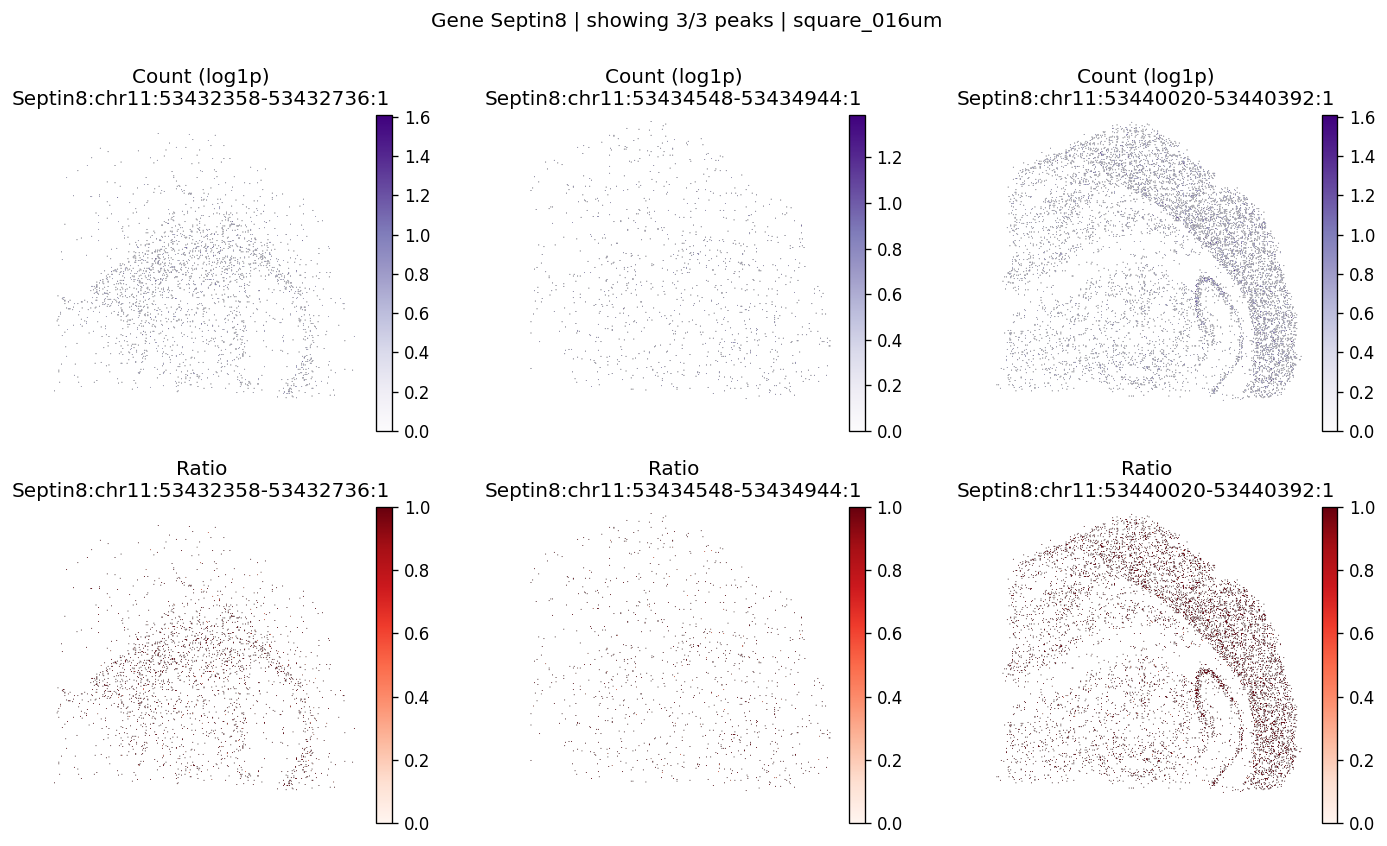

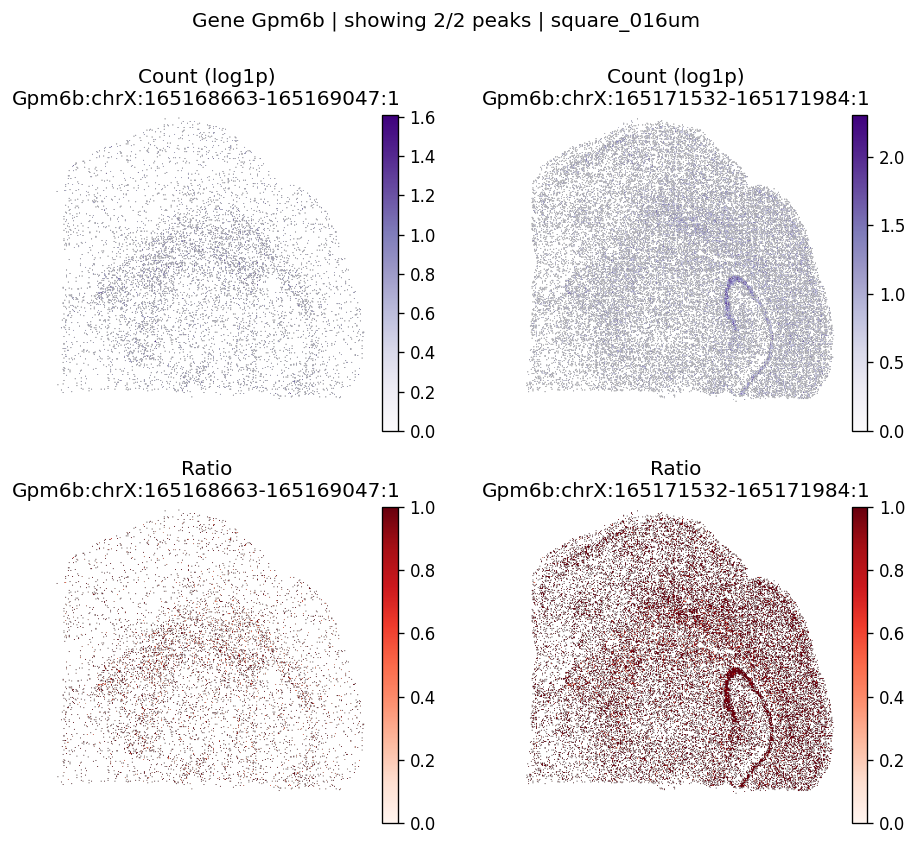

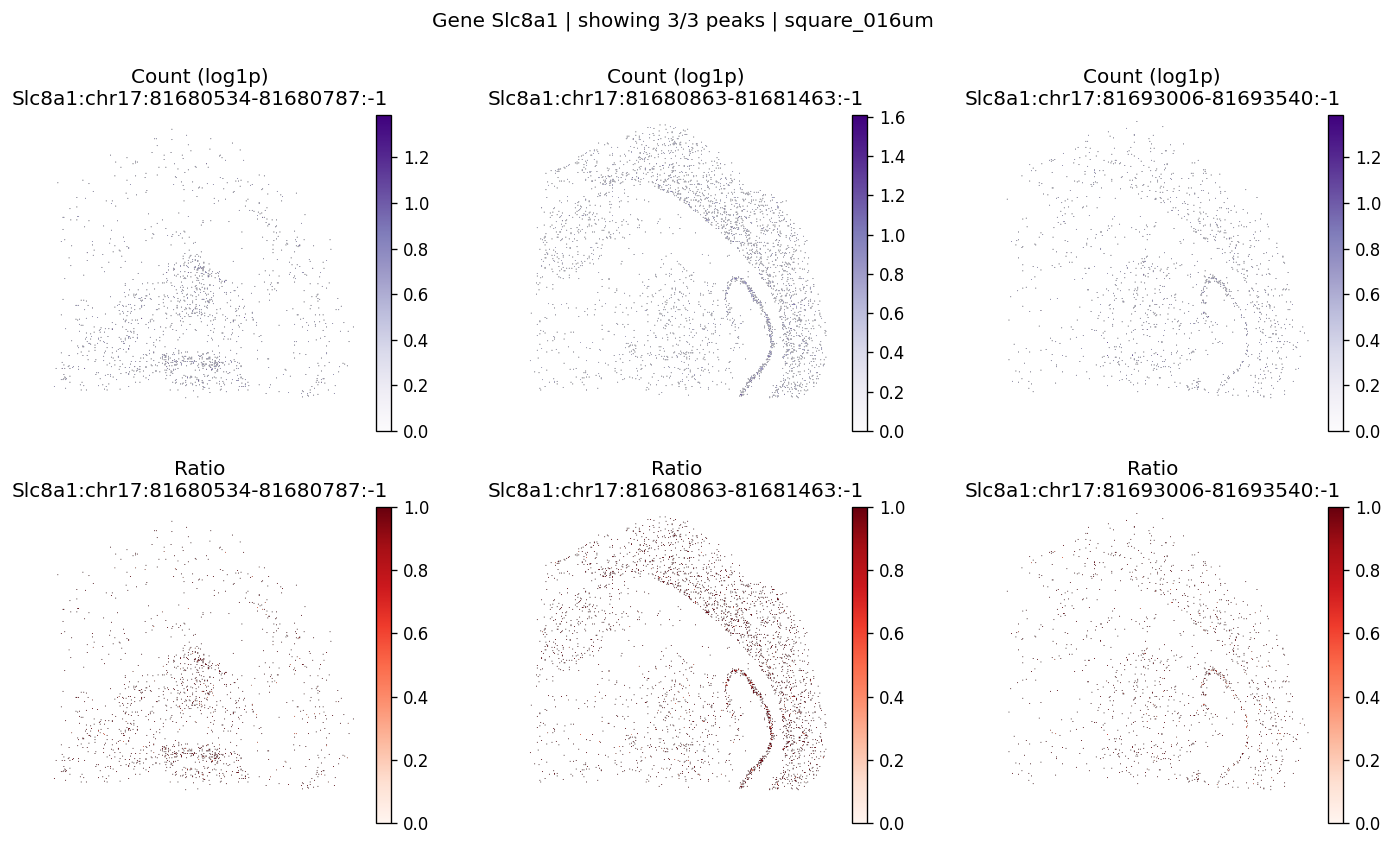

In [20]:
for gene_id in top_genes[:3]:
    plot_gene_peak_maps(
        sdata=sdata,
        bin_table=test_table,
        bin_element=test_bins_element,
        gene_id=gene_id,
        group_col='gene_ids',
        max_peaks=6,
        peak_meta=peak_meta,
        hide_zero_ratio=True,
    )

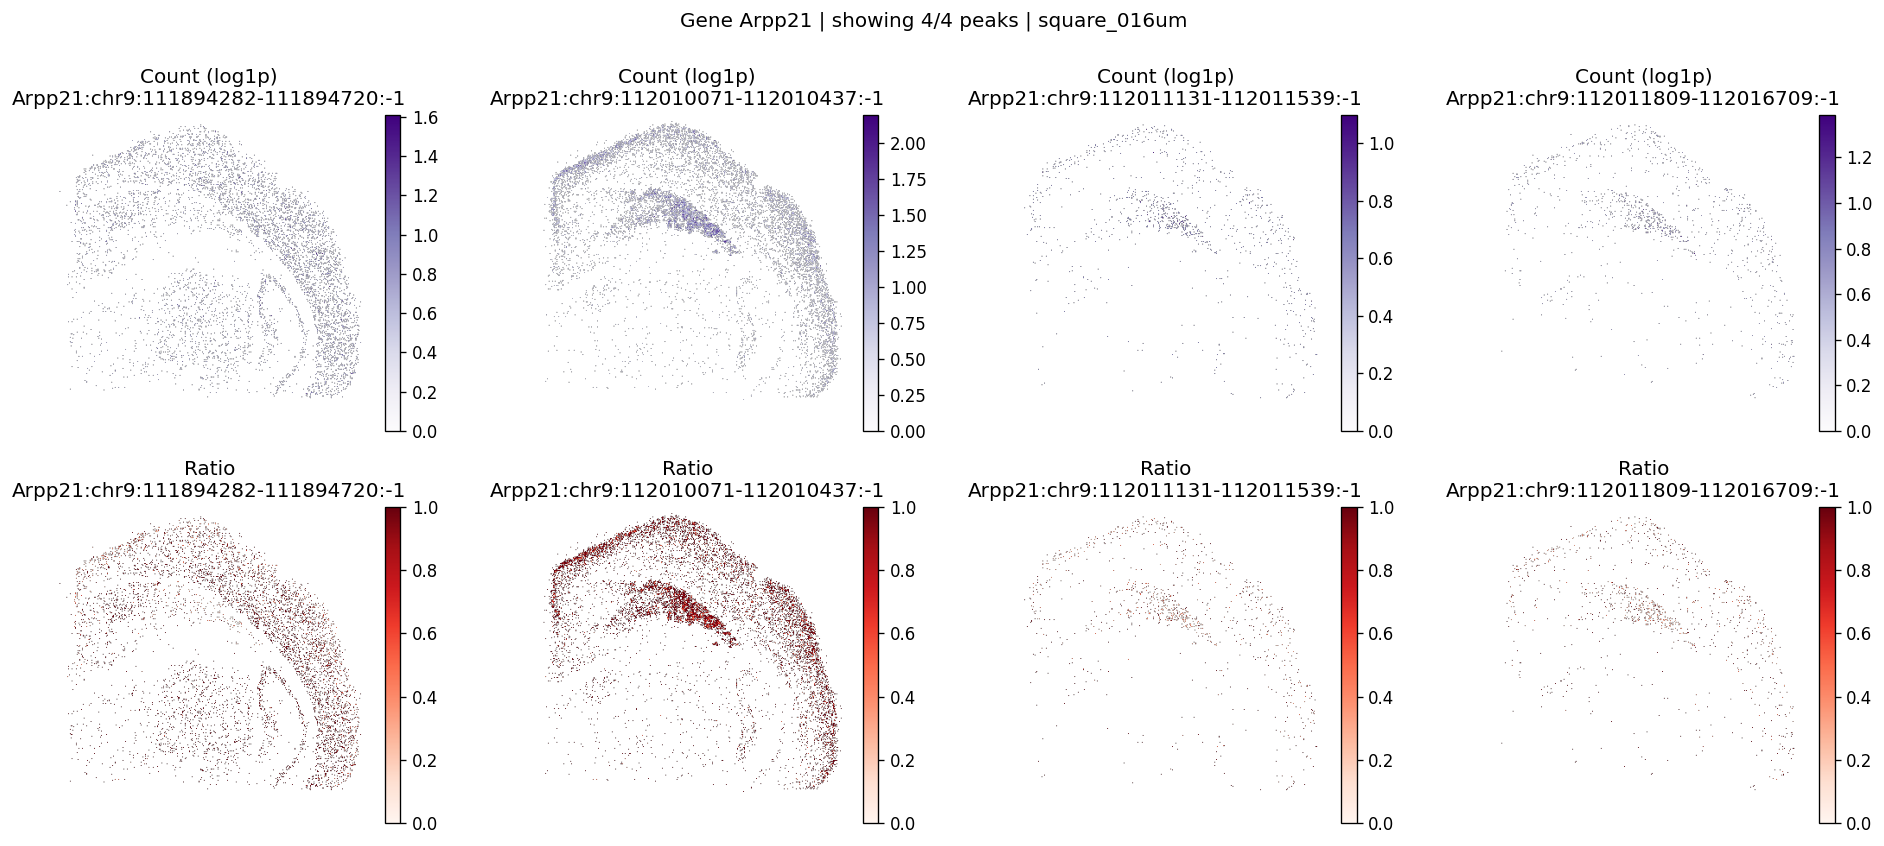

CPU times: user 264 ms, sys: 20.1 ms, total: 284 ms
Wall time: 283 ms


In [21]:
%%time
# Example: inspect a specific gene manually
plot_gene_peak_maps(
    sdata, test_table, test_bins_element, 
    gene_id="Arpp21", 
    group_col='gene_ids', 
    peak_meta=peak_meta
)

To see the spatially variable transcript regions, we can visualize TREND peaks along with a matched transcript reference. The following files need to be downloaded and provided as input:
- `peak.txt.bed12` from the Sierra peak calling output (see `scripts/visiumhd_3p_trend_quant.sh` for details)
- `gencode.vM33.annotation.gtf.gz` from [GENCODE](https://www.gencodegenes.org/mouse/releases.html)

In [22]:
def plot_peak_transcript_structure(
    gene_name: str,
    bed12_file: str | Path,
    gtf_file: str | Path,
    figsize: tuple[float, float] = (12, 7),
    transcript_label: str = "transcript_name",
):
    """Visualize BED12 peaks and transcript exon structure for one gene.

    The BED12 peak model is rendered with block-level segments, and transcript
    structures are drawn in the same style as plot_probe_transcript_structure:
    introns as thin lines and exons as thicker boxes with transcript labels.
    """
    import gzip

    bed12_file = Path(bed12_file)
    gtf_file = Path(gtf_file)

    # BED12 schema used by Sierra peak output.
    bed_cols = [
        "chrom", "start", "end", "name", "score", "strand",
        "thickStart", "thickEnd", "itemRgb", "blockCount", "blockSizes", "blockStarts",
    ]
    peaks = pd.read_csv(
        bed12_file,
        sep="\t",
        header=None,
        names=bed_cols,
        usecols=list(range(12)),
    )

    # Parse peak name format: GENE:chr:start-end:strand
    peaks["gene"] = peaks["name"].astype(str).str.split(":", n=1).str[0]
    peaks["peak_id"] = peaks["name"].astype(str).str.split(":", n=1).str[1]
    peaks["peak_id"] = peaks["peak_id"].fillna(peaks["name"])

    peaks = peaks[peaks["gene"].str.lower() == str(gene_name).lower()].copy()
    if peaks.empty:
        warnings.warn(f"No BED12 peaks found for gene '{gene_name}' in {bed12_file}")

    # Convert BED12 blocks to absolute genomic coordinates per peak.
    def parse_blocks(row: pd.Series) -> list[tuple[int, int]]:
        starts = [int(x) for x in str(row["blockStarts"]).strip(",").split(",") if x != ""]
        sizes = [int(x) for x in str(row["blockSizes"]).strip(",").split(",") if x != ""]
        n = min(int(row["blockCount"]), len(starts), len(sizes))
        blocks = []
        for i in range(n):
            block_start = int(row["start"]) + starts[i]
            block_end = block_start + sizes[i]
            blocks.append((block_start, block_end))
        return blocks

    if not peaks.empty:
        peaks["blocks"] = peaks.apply(parse_blocks, axis=1)

    # Open plain-text or gzipped GTF seamlessly.
    if str(gtf_file).endswith(".gz"):
        gtf_opener = lambda f: gzip.open(f, "rt")
    else:
        gtf_opener = open

    # Collect exon structures keyed by transcript_id.
    transcripts_by_id = {}
    with gtf_opener(gtf_file) as f:
        for line in f:
            if line.startswith("#"):
                continue
            fields = line.rstrip("\n").split("\t")
            if len(fields) < 9 or fields[2] != "exon":
                continue

            start, end = int(fields[3]), int(fields[4])
            attrs = {}
            for attr in fields[8].split(";"):
                attr = attr.strip()
                if not attr or " " not in attr:
                    continue
                k, v = attr.split(" ", 1)
                attrs[k] = v.strip().strip('"')

            if attrs.get("gene_name", "").lower() != str(gene_name).lower() and attrs.get("gene_id", "").lower() != str(gene_name).lower():
                continue

            tx_id = attrs.get("transcript_id", "unknown")
            if tx_id not in transcripts_by_id:
                tx_name = attrs.get(transcript_label) or attrs.get("transcript_name") or tx_id
                transcripts_by_id[tx_id] = {
                    "tx_name": tx_name,
                    "strand": fields[6],
                    "exons": [],
                }
            transcripts_by_id[tx_id]["exons"].append((start, end))

    if not transcripts_by_id:
        warnings.warn(f"No matching transcripts found for gene '{gene_name}' in {gtf_file}")

    fig, ax = plt.subplots(figsize=figsize)

    y_pos = 0
    x_mins = []
    x_maxs = []

    # Strand color coding for cleaner direction cues.
    strand_colors = {
        "+": "steelblue",
        "-": "darkorange",
    }

    # Draw transcripts first using the same visual language as probe plotting.
    for tx_id, tx_info in sorted(transcripts_by_id.items()):
        exons = sorted(tx_info["exons"])
        if not exons:
            continue

        min_coord = min(e[0] for e in exons)
        max_coord = max(e[1] for e in exons)
        x_mins.append(min_coord)
        x_maxs.append(max_coord)

        strand = str(tx_info.get("strand", "."))
        tx_color = strand_colors.get(strand, "gray")

        # Introns: thin baseline
        ax.plot([min_coord, max_coord], [y_pos, y_pos], "k-", linewidth=0.5, alpha=0.5)

        # Exons: thicker boxes (color by strand)
        for exon_start, exon_end in exons:
            ax.barh(
                y_pos,
                exon_end - exon_start,
                left=exon_start,
                height=0.6,
                color=tx_color,
                edgecolor="black",
            )

        # Transcript label (same style as probe-based helper)
        tx_name = str(tx_info.get("tx_name", tx_id))
        ax.text(
            min_coord - (max_coord - min_coord) * 0.05,
            y_pos,
            tx_name[:30],
            ha="right",
            va="center",
            fontsize=8,
        )

        y_pos += 1

    # Plot peaks after transcripts, one row per peak to avoid overlap.
    peak_rows_start = y_pos
    peak_rows = peaks.sort_values(["chrom", "start", "end"]) if not peaks.empty else peaks

    for i, (_, row) in enumerate(peak_rows.iterrows()):
        peak_y = peak_rows_start + i
        blocks = row["blocks"] if isinstance(row["blocks"], list) and row["blocks"] else [(int(row["start"]), int(row["end"]))]
        peak_min = min(b[0] for b in blocks)
        peak_max = max(b[1] for b in blocks)
        x_mins.append(peak_min)
        x_maxs.append(peak_max)

        # Span and block model for each peak.
        ax.plot([peak_min, peak_max], [peak_y, peak_y], color="firebrick", linewidth=0.7, alpha=0.6)
        for block_start, block_end in blocks:
            ax.barh(
                peak_y,
                block_end - block_start,
                left=block_start,
                height=0.45,
                color="salmon",
                edgecolor="firebrick",
            )

    x_pad = max(1.0, (max(x_maxs) - min(x_mins)) * 0.02) if x_mins and x_maxs else 1.0

    # Peak labels are shown on the left side, one per row.
    for i, (_, row) in enumerate(peak_rows.iterrows()):
        peak_y = peak_rows_start + i
        blocks = row["blocks"] if isinstance(row["blocks"], list) and row["blocks"] else [(int(row["start"]), int(row["end"]))]
        peak_min = min(b[0] for b in blocks)
        ax.text(
            peak_min - x_pad,
            peak_y,
            str(row["peak_id"]),
            va="center",
            ha="right",
            fontsize=7,
            color="firebrick",
        )

    total_rows = max(y_pos, peak_rows_start + len(peak_rows))
    ax.set_ylim(-0.8, total_rows + 0.8)
    ax.set_yticks([])
    ax.set_xlabel("Genomic coordinate (bp)")
    ax.set_title(f"Peak and transcript structure: {gene_name}")
    ax.grid(True, axis="x", alpha=0.3)

    # Place strand direction note as a single centered row below the plot.
    direction_note = "Transcript 5'->3' direction: + strand left->right (blue) | - strand right->left (orange)"
    fig.text(0.5, 0.01, direction_note, ha="center", va="bottom", fontsize=10, color="black")

    # Reserve bottom margin for the legend row.
    fig.tight_layout(rect=(0.0, 0.05, 1.0, 1.0))
    plt.show()

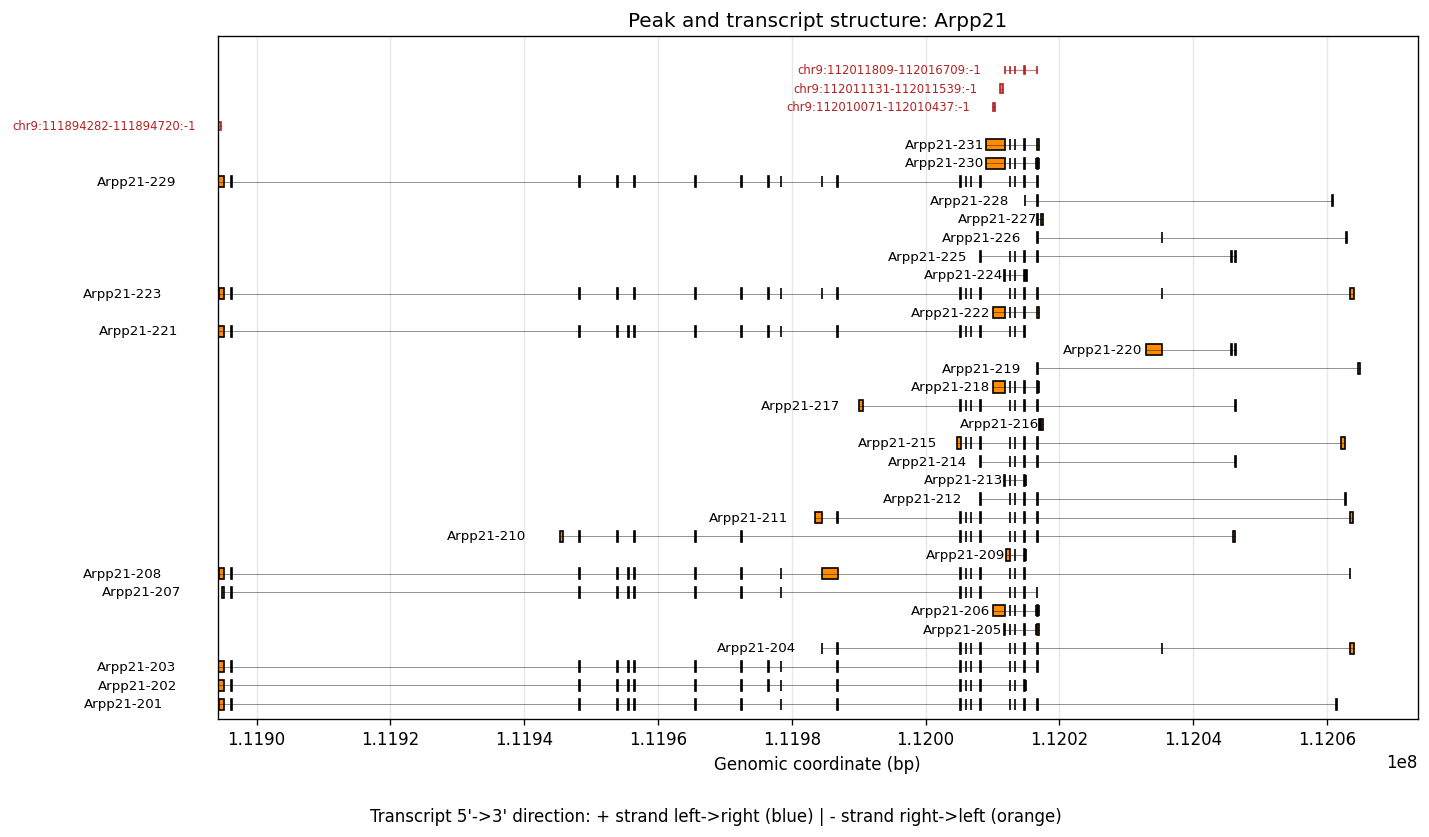

CPU times: user 4.24 s, sys: 37.8 ms, total: 4.28 s
Wall time: 4.3 s


In [23]:
%%time
plot_peak_transcript_structure(
    gene_name="Arpp21",
    bed12_file=bed12_file,
    gtf_file=gtf_file,
)

## Advanced analyses

### Spatial resolution comparison

For illustration, we use the top 200 genes from the 16µm analysis as the reference set:

In [24]:
# np.random.seed(42)
# gene_names = sdata.tables[test_table].var['gene_ids'].unique()
# gene_subset = np.random.choice(gene_names, size=500, replace=False)
gene_subset = sv_res_16um.sort_values('pvalue').head(500)['gene'].astype(str).tolist()

Run spatial variability tests across all three resolutions:

In [25]:
%%time
# Compare results across 2µm, 8µm, 16µm resolutions
resolutions = [
    {'bin': f'{dataset_id}_square_002um', 'table_name': 'square_002um'},
    {'bin': f'{dataset_id}_square_008um', 'table_name': 'square_008um'},
    {'bin': f'{dataset_id}_square_016um', 'table_name': 'square_016um'},
]

res_results = []
for res in resolutions:
    m = SplisosmFFT(neighbor_degree=1, rho=0.99)
    sdata_subset = sd.filter_by_table_query(
        sdata,
        table_name=res['table_name'],
        var_expr=an.col(gene_name_col).is_in(gene_subset),
    )
    m.setup_data(
        sdata_subset,
        bins=res['bin'],
        table_name=res['table_name'],
        col_key="array_col",
        row_key="array_row",
        layer="counts",
        group_iso_by=group_iso_by,
        gene_names=gene_name_col,
        min_counts=min_counts,
        min_bin_pct=0.0
    )
    m.test_spatial_variability(method='hsic-ir')
    results = m.get_formatted_test_results('sv')[['gene', 'pvalue']].copy()
    results.rename(columns={'pvalue': f"p_{res['table_name']}"}, inplace=True)
    res_results.append(results)

SV [hsic-ir]:   0%|          | 0/500 [00:00<?, ?it/s]

SV [hsic-ir]:   4%|▍         | 20/500 [00:05<02:17,  3.48it/s]

SV [hsic-ir]:   6%|▌         | 30/500 [00:13<03:45,  2.09it/s]

SV [hsic-ir]:   6%|▌         | 31/500 [00:13<03:38,  2.15it/s]

SV [hsic-ir]:   8%|▊         | 40/500 [00:18<04:02,  1.90it/s]

...

SV [hsic-ir]:  94%|█████████▍| 470/500 [00:04<00:00, 74.30it/s]

SV [hsic-ir]:  96%|█████████▌| 480/500 [00:04<00:00, 79.17it/s]

SV [hsic-ir]:  98%|█████████▊| 490/500 [00:05<00:00, 76.59it/s]

SV [hsic-ir]: 100%|██████████| 500/500 [00:05<00:00, 96.56it/s]

CPU times: user 21min 25s, sys: 11min 33s, total: 32min 58s
Wall time: 6min 36s


In [26]:
merged = res_results[0]
for res in res_results[1:]:
    merged = merged.merge(res, on="gene", how="inner")

p_cols = [c for c in merged.columns if c.startswith("p_")]
print("Spearman correlation across spatial resolutions:")
display(merged[p_cols].corr(method="spearman"))

Spearman correlation across spatial resolutions:


,p_square_002um,p_square_008um,p_square_016um
p_square_002um,1.000000,0.759201,0.629610
p_square_008um,0.759201,1.000000,0.901705
p_square_016um,0.629610,0.901705,1.000000


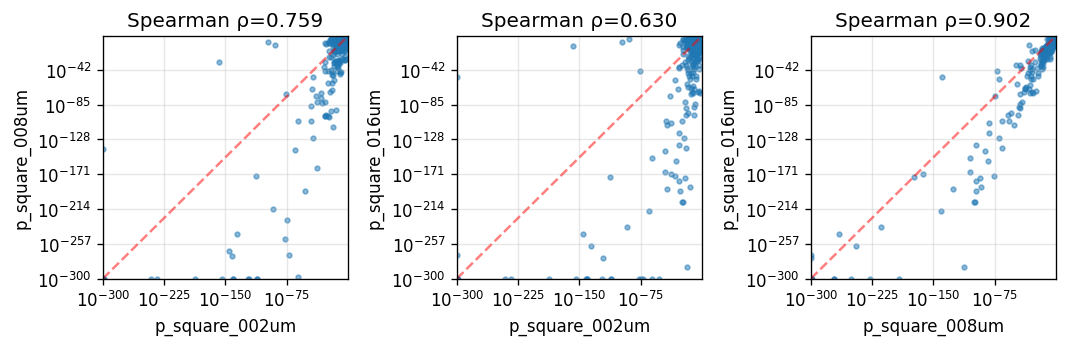

In [27]:
pairs = list(combinations(p_cols, 2))
if pairs:
    fig, axes = plt.subplots(1, len(pairs), figsize=(3 * len(pairs), 3), squeeze=False)
    axes = axes.ravel()

    for ax, (x_col, y_col) in zip(axes, pairs):
        x = merged[x_col].to_numpy()
        y = merged[y_col].to_numpy()
        corr, pval = spearmanr(x, y)

        ax.scatter(x + 1e-300, y + 1e-300, s=8, alpha=0.5)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"Spearman ρ={corr:.3f}")
        ax.grid(True, alpha=0.3)

        low = 1e-300
        high = max(np.max(x), np.max(y))
        ax.plot([low, high], [low, high], "r--", alpha=0.5, linewidth=1.5)
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)

    plt.tight_layout()
    plt.show()

Gene rankings are broadly consistent across resolutions, especially between 16µm and 8µm, with the 16µm analysis showing the strongest statistical significance.

### Method comparison: `SplisosmFFT` vs `SplisosmNP`

We now compare FFT-accelerated and non-parametric spatial variability tests at 16 µm resolution.

**Note: The low-rank SV path (previously the default for `n>5000`) is no longer the default**. 
Null cumulants are now estimated from the **full-rank** spatial kernel using Hutchinson's trace estimator.
Use `null_configs={"n_probes": m}` to control the Hutchinson trace budget. A smaller `m` reduces runtime but may decrease accuracy.

If you need to reproduce the legacy low-rank behavior, you can explicitly pass ``null_configs={"approx_rank": k}``. 
Note that this approximation prioritizes global pattern detection **at the expense of zero power to local variation**. 
If global patterns are your primary focus, we recommend using the full-rank test with a higher `rho` value (e.g., `0.999`) instead to balance sensitivity across a wider range of spatial patterns.

In [28]:
%%time
# Run SplisosmNP at 16µm for direct comparison with SplisosmFFT
model_np = SplisosmNP(
    k_neighbors=4,
    rho=0.99,
    standardize_cov=False, # turn off for faster runtime
)
model_np.setup_data(
    adata=sdata.tables[test_table],
    spatial_key='spatial', # adata.obsm key for spatial coordinates
    layer='counts',
    group_iso_by=group_iso_by, # 'gene_ids'
    gene_names=gene_name_col, # 'gene_ids'
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    filter_single_iso_genes=True,
    min_component_size=10 # remove disconnected tissue fragments if any
)

/Users/jysumac/Projects/SPLISOSM/splisosm/hyptest_np.py:604: UserWarning: Removed 30 spot(s) belonging to graph components with fewer than 10 member(s). 94562 spot(s) remain.
  ) = prepare_inputs_from_anndata(


CPU times: user 827 ms, sys: 328 ms, total: 1.15 s
Wall time: 1.19 s


In [29]:
%%time
model_np.test_spatial_variability(
    method='hsic-ir',
    null_configs={"n_probes": 60},
    ratio_transformation='none',
    print_progress=True,
)

SV [hsic-ir]:   0%|          | 0/1061 [00:00<?, ?it/s]

SV [hsic-ir]:   4%|▍         | 40/1061 [00:00<00:03, 325.58it/s]

SV [hsic-ir]:   7%|▋         | 73/1061 [00:00<00:03, 297.71it/s]

SV [hsic-ir]:  10%|▉         | 103/1061 [00:00<00:03, 249.83it/s]

SV [hsic-ir]:  12%|█▏        | 129/1061 [00:00<00:04, 216.77it/s]

...

SV [hsic-ir]:  97%|█████████▋| 1030/1061 [00:08<00:00, 106.05it/s]

SV [hsic-ir]:  99%|█████████▉| 1050/1061 [00:08<00:00, 107.10it/s]

SV [hsic-ir]: 100%|██████████| 1061/1061 [00:08<00:00, 105.68it/s]

SV [hsic-ir]: 100%|██████████| 1061/1061 [00:08<00:00, 118.66it/s]

CPU times: user 44.1 s, sys: 6.11 s, total: 50.3 s
Wall time: 9.88 s


Compare p-values between `SplisosmFFT` and `SplisosmNP`:

In [30]:
# Extract results and merge
sv_np = model_np.get_formatted_test_results('sv')[['gene', 'pvalue']].copy()
sv_np = sv_np.rename(columns={'pvalue': 'pvalue_np'})

comparison = sv_res_16um[['gene', 'pvalue']].copy()
comparison = comparison.rename(columns={'pvalue': 'pvalue_fft'})
comparison = comparison.merge(sv_np, on='gene', how='inner')

corr, _ = spearmanr(comparison['pvalue_fft'], comparison['pvalue_np'])

print(f'Genes tested in both methods: {len(comparison)}')
print(f'== Significant in SplisosmFFT (FDR < 0.01): {(comparison["pvalue_fft"] < 0.01).sum()}')
print(f'== Significant in SplisosmNP (FDR < 0.01): {(comparison["pvalue_np"] < 0.01).sum()}')
print(f'== P-value correlation (Spearman rho): {corr:.4f}')

Genes tested in both methods: 1061
== Significant in SplisosmFFT (FDR < 0.01): 540
== Significant in SplisosmNP (FDR < 0.01): 342
== P-value correlation (Spearman rho): 0.9968


The two approaches yield almost identical rankings. `SplisosmFFT` shows slightly smaller p-values for top genes due to zero-padding that increases sample size (`n=94,592` before vs `n=134,688` after rasterization).

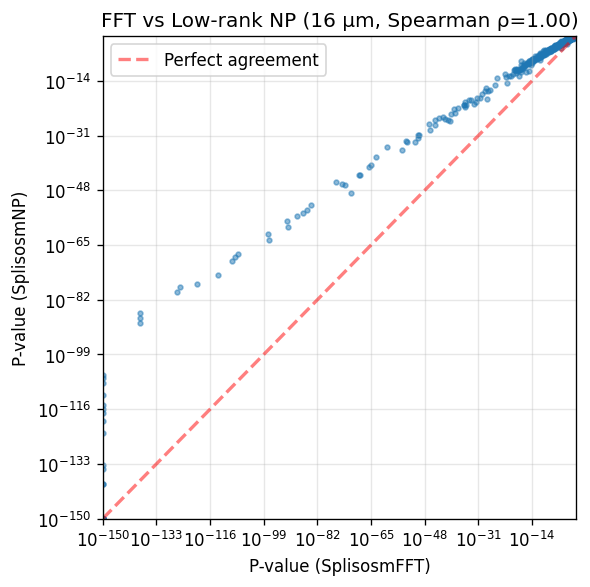

In [31]:
# Scatter plot comparison
fig, ax = plt.subplots(figsize=(5, 5))
x = comparison['pvalue_fft'].to_numpy()
y = comparison['pvalue_np'].to_numpy()

ax.scatter(x + 1e-150, y + 1e-150, s=8, alpha=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('P-value (SplisosmFFT)')
ax.set_ylabel('P-value (SplisosmNP)')
ax.set_title(f'FFT vs Low-rank NP (16 µm, Spearman ρ={corr:.2f})')
ax.grid(True, alpha=0.3)

# Add diagonal reference line
lims = [1e-150, 1.0]
ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect agreement', linewidth=2)
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.show()

### Summary and recommendations

**Key findings:**

1. **Spatial variability is robustly detectable** in this Visium HD 3' peak-level dataset using `SplisosmFFT` on regular grids.

2. **Spatial resolution trade-offs:**
   - **16 um**: Fast and reliable - recommended for initial exploration.
   - **8 um**: High agreement with 16 um results.
   - **2 um**: Highest resolution but slower and sparser.

3. `SplisosmFFT` and `SplisosmNP` yield concordant rankings on regular grids.

**Recommendations:**

- Start with **16 um** binning for exploratory analysis; refine with **8 um** if finer spatial detail is needed.
- Use **SplisosmFFT** on regular grids (Visium HD, Xenium binned data) with `neighbor_degree=1, rho=0.99` as a robust default; use **SplisosmNP** for irregular geometries (e.g., cell-segmented data).

## For reproducibility

In [32]:
import sys
from datetime import date
import splisosm

print("Last updated:", date.today())
print("Python:", sys.version.split()[0])
print("splisosm:", getattr(splisosm, "__version__", "unknown"))

Last updated: 2026-04-26
Python: 3.12.13
splisosm: 1.2.0rc1
